# 04 - Model Evaluation

## Objective

The objective of this notebook is to evaluate the trained machine learning model using different evaluation metrics and visualization techniques.

### Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- Classification Report

Finally, the trained model will be saved for deployment in the Streamlit dashboard.

In [1]:
# =====================================================
# Import Required Libraries
# =====================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

import joblib

## Load Processed Dataset

In [2]:
# Load processed dataset

df = pd.read_csv("../data/student_performance.csv")

df.head()

,Attendance_Percentage,Quiz_Average,Marks,Assignment_Average,Weekly_Study_Hours,Average_Session_Duration,Engagement_Score,Sessions_Per_Week,Performance
0,80.8,37.736667,69.333333,65.0,16.3,35,84.9,4,Average
1,67.4,61.533333,83.000000,40.8,23.5,52,98.5,9,High Performer
2,71.1,67.313333,71.000000,48.8,9.7,69,61.1,4,Average
3,66.7,82.231667,60.666667,33.4,19.8,169,85.4,2,Average
4,81.7,64.335000,38.666667,41.8,14.3,144,82.9,4,At Risk


## Separate Features and Target

In [3]:
X = df.drop("Performance", axis=1)

y = df["Performance"]

## Split Dataset

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
## Load Trained Model

In [6]:
model = joblib.load("../models/student_model.pkl")

## Model Prediction

In [7]:
y_pred = model.predict(X_test)

## Accuracy Score

In [8]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2f}")

Accuracy : 1.00


## Precision, Recall and F1 Score

In [9]:
precision = precision_score(y_test, y_pred, average="weighted")

recall = recall_score(y_test, y_pred, average="weighted")

f1 = f1_score(y_test, y_pred, average="weighted")

print("Precision :", precision)

print("Recall :", recall)

print("F1 Score :", f1)

Precision : 1.0
Recall : 1.0
F1 Score : 1.0


## Classification Report

In [10]:
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

       At Risk       1.00      1.00      1.00        97
       Average       1.00      1.00      1.00       275
High Performer       1.00      1.00      1.00        28

      accuracy                           1.00       400
     macro avg       1.00      1.00      1.00       400
  weighted avg       1.00      1.00      1.00       400



## Confusion Matrix

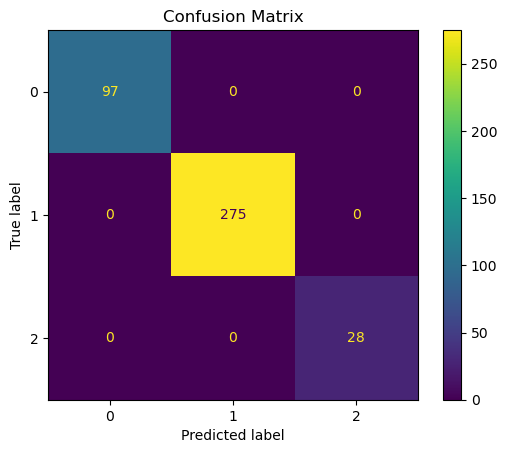

In [11]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

plt.title("Confusion Matrix")

plt.show()

## Feature Importance

In [12]:
importance = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
2,Marks,0.895922
1,Quiz_Average,0.018976
4,Weekly_Study_Hours,0.016699
3,Assignment_Average,0.016304
0,Attendance_Percentage,0.016212
5,Average_Session_Duration,0.014739
6,Engagement_Score,0.012103
7,Sessions_Per_Week,0.009044


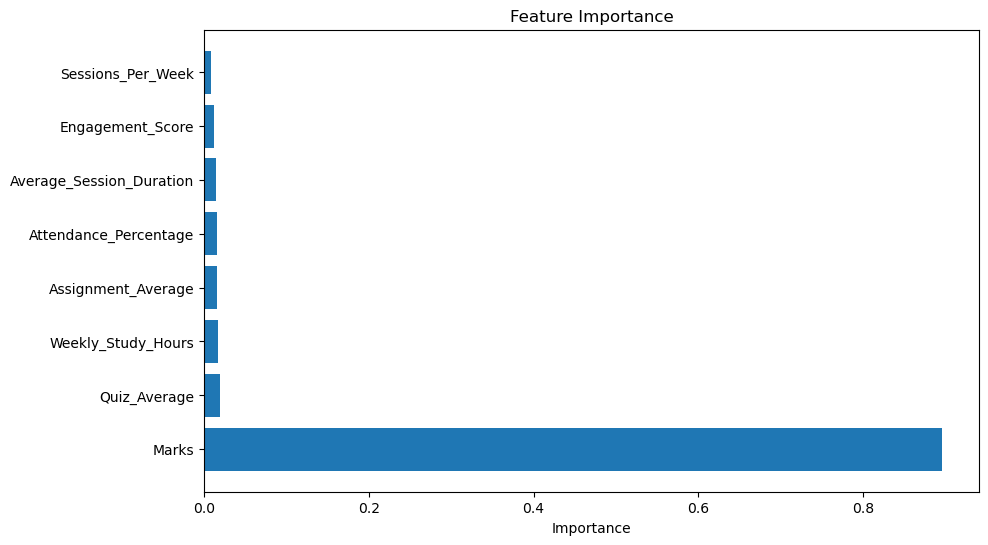

In [13]:
plt.figure(figsize=(10,6))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.title("Feature Importance")

plt.xlabel("Importance")

plt.show()

## Save Model

In [14]:
joblib.dump(model, "../models/student_model.pkl")

print("Model saved successfully.")

Model saved successfully.


# Conclusion

The trained model was evaluated using multiple performance metrics.

## Results

- Accuracy was calculated.
- Precision, Recall and F1 Score were measured.
- Classification Report was generated.
- Confusion Matrix visualized prediction performance.
- Feature Importance identified the most influential variables.

The trained model has been successfully saved for deployment in the Streamlit dashboard.